# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Kiểm tra cấu trúc và chất lượng dữ liệu

audit_table = pd.DataFrame({
    "dtype": X_raw.dtypes.astype(str),
    "missing": X_raw.isna().sum(),
    "zero_count": (X_raw == 0).sum(),
    "unique_count": X_raw.nunique(),
    "min": X_raw.min(),
    "median": X_raw.median(),
    "mean": X_raw.mean(),
    "max": X_raw.max(),
    "skew": X_raw.skew()
})

print("Số dòng trùng lặp:", df.duplicated().sum())
print("Tổng số missing:", X_raw.isna().sum().sum())

display(audit_table)

print("\nThống kê chi tiết:")
display(
    X_raw.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).T
)

# Kiểm tra Channel và Region nếu có
for context_col in ["Channel", "Region"]:
    if context_col in df.columns:
        print(f"\nPhân bố {context_col}:")
        display(df[context_col].value_counts().sort_index())

Số dòng trùng lặp: 0
Tổng số missing: 0


,dtype,missing,zero_count,unique_count,min,median,mean,max,skew
Fresh,int64,0,0,433,3,"8,504.00","12,000.30",112151,2.56
Milk,int64,0,0,421,55,"3,627.00","5,796.27",73498,4.05
Grocery,int64,0,0,430,3,"4,755.50","7,951.28",92780,3.59
Frozen,int64,0,0,426,25,"1,526.00","3,071.93",60869,5.91
Detergents_Paper,int64,0,0,417,3,816.50,"2,881.49",40827,3.63
Delicassen,int64,0,0,403,3,965.50,"1,524.87",47943,11.15



Thống kê chi tiết:


,count,mean,std,min,1%,25%,50%,75%,99%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,28.46,"3,127.75","8,504.00","16,933.75","56,082.61","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,255.56,"1,533.00","3,627.00","7,190.25","37,610.06","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,259.82,"2,153.00","4,755.50","10,655.75","43,435.74","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,43.95,742.25,"1,526.00","3,554.25","17,964.82","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,9.39,256.75,816.50,"3,922.00","22,571.61","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,7.39,408.25,965.50,"1,820.25","8,274.66","47,943.00"



Phân bố Channel:


Channel
1    298
2    142
Name: count, dtype: int64

### Nhận xét TODO A

Mỗi dòng dữ liệu đại diện cho một khách hàng của nhà phân phối thực phẩm. Sáu biến `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper` và `Delicassen` thể hiện mức chi tiêu hằng năm của khách hàng ở từng nhóm sản phẩm.

Các biến này phù hợp cho bài toán segmentation vì chúng phản ánh trực tiếp hành vi mua hàng. `Channel` và `Region` không được dùng làm input clustering ban đầu vì em muốn các cụm được hình thành từ hành vi chi tiêu, thay vì bị định hướng sẵn bởi loại kênh bán hàng hoặc khu vực. Sau khi có cụm, hai biến này có thể được dùng để kiểm tra xem cụm có liên quan đến bối cảnh kinh doanh nào không.

Trong bài này, một segmentation được xem là hữu ích khi các cụm có quy mô đủ lớn, có pattern chi tiêu khác nhau rõ ràng, tương đối ổn định và có thể dẫn đến những giả thuyết hành động khác nhau.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

Phân phối dữ liệu gốc

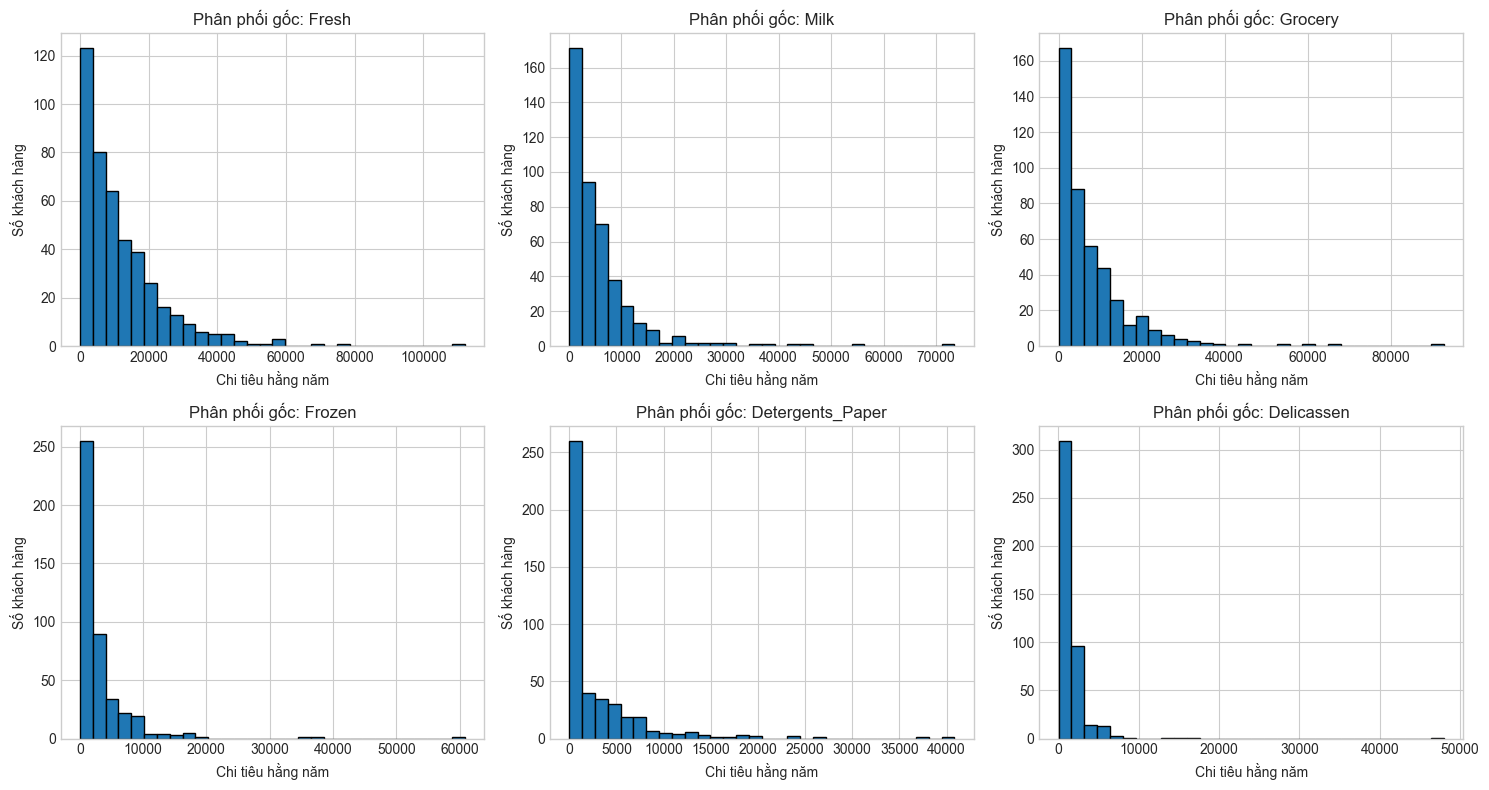

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, SPENDING_FEATURES):
    ax.hist(X_raw[col], bins=30, edgecolor="black")
    ax.set_title(f"Phân phối gốc: {col}")
    ax.set_xlabel("Chi tiêu hằng năm")
    ax.set_ylabel("Số khách hàng")

plt.tight_layout()
plt.show()

So sánh độ lệch trước và sau log

,skew_raw,skew_log1p
Fresh,2.56,-1.58
Milk,4.05,-0.22
Grocery,3.59,-0.67
Frozen,5.91,-0.35
Detergents_Paper,3.63,-0.24
Delicassen,11.15,-1.09


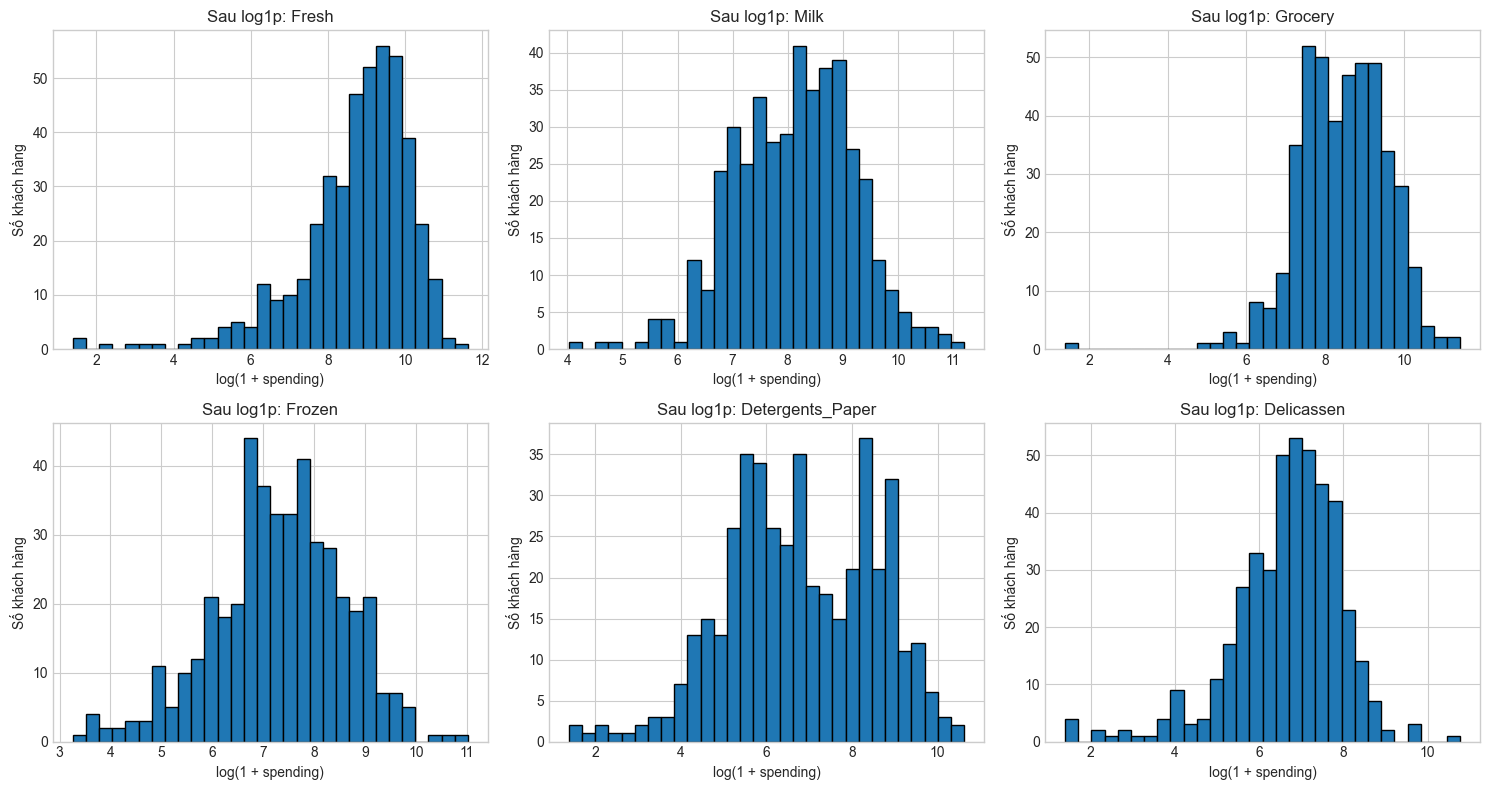

In [5]:
X_log = np.log1p(X_raw)

skew_comparison = pd.DataFrame({
    "skew_raw": X_raw.skew(),
    "skew_log1p": X_log.skew()
})

display(skew_comparison)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, SPENDING_FEATURES):
    ax.hist(X_log[col], bins=30, edgecolor="black")
    ax.set_title(f"Sau log1p: {col}")
    ax.set_xlabel("log(1 + spending)")
    ax.set_ylabel("Số khách hàng")

plt.tight_layout()
plt.show()

Correlation

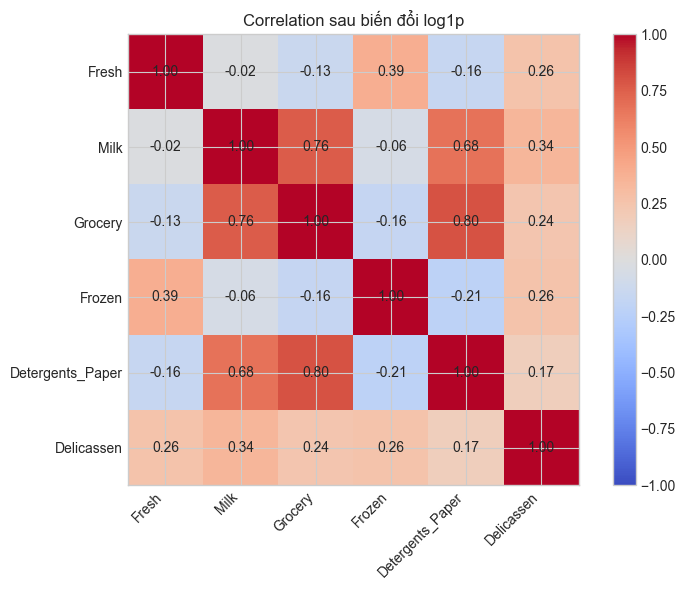

In [6]:
corr_log = X_log.corr()

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(corr_log, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(SPENDING_FEATURES)))
ax.set_yticks(range(len(SPENDING_FEATURES)))
ax.set_xticklabels(SPENDING_FEATURES, rotation=45, ha="right")
ax.set_yticklabels(SPENDING_FEATURES)

for i in range(len(SPENDING_FEATURES)):
    for j in range(len(SPENDING_FEATURES)):
        ax.text(
            j,
            i,
            f"{corr_log.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(image, ax=ax)
plt.title("Correlation sau biến đổi log1p")
plt.tight_layout()
plt.show()

### Nhận xét TODO B

Các biến chi tiêu gốc có phân phối lệch phải và xuất hiện một số giá trị rất lớn. Điều này có thể làm khoảng cách Euclid bị chi phối bởi một vài khách hàng có mức chi tiêu cực cao.

Sau khi dùng `log1p`, độ lệch của phần lớn biến giảm rõ rệt. Biến đổi này vẫn giữ thứ tự tương đối giữa các khách hàng nhưng làm giảm ảnh hưởng của các điểm cực trị.

Ma trận tương quan cho thấy một số nhóm chi tiêu có xu hướng đi cùng nhau. Những mối quan hệ này cần được xem lại khi đọc profile cụm, vì một cụm có mức chi tiêu cao ở một biến có thể đồng thời cao ở một số biến liên quan.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [7]:
# Candidate 1: log1p + StandardScaler
X_log = np.log1p(X_raw)

standard_scaler = StandardScaler()
X_model = standard_scaler.fit_transform(X_log)

# Candidate 2 dùng cho kiểm tra robustness
robust_scaler = RobustScaler()
X_model_robust = robust_scaler.fit_transform(X_log)

print("Shape X_model:", X_model.shape)

print("\nMean sau StandardScaler:")
print(np.round(X_model.mean(axis=0), 4))

print("\nStd sau StandardScaler:")
print(np.round(X_model.std(axis=0), 4))

Shape X_model: (440, 6)

Mean sau StandardScaler:
[ 0. -0. -0.  0. -0. -0.]

Std sau StandardScaler:
[1. 1. 1. 1. 1. 1.]


### Lựa chọn representation

Matrix chính dùng để fit model là `StandardScaler(log1p(X_raw))`.

Em dùng `log1p` để giảm độ lệch phải và hạn chế ảnh hưởng của các khách hàng chi tiêu cực lớn. Sau đó dùng StandardScaler để đưa các feature về thang đo tương đương, tránh việc feature có độ lớn cao chi phối khoảng cách.

Em vẫn giữ nguyên `X_raw` để profile và diễn giải cụm bằng đơn vị chi tiêu ban đầu.

Trade-off của cách làm này là khoảng cách trong không gian sau log không còn tương ứng trực tiếp với chênh lệch tiền tuyệt đối. Một khách hàng chi tiêu gấp đôi khách hàng khác sẽ không còn cách xa đúng gấp đôi trong representation dùng để clustering.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [8]:
def clustering_metrics(X, labels):
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return np.nan, np.nan

    silhouette = silhouette_score(X, labels)
    db_score = davies_bouldin_score(X, labels)

    return silhouette, db_score


results = []
candidate_labels = {}

for k in range(2, 9):
    # K-Means
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )

    labels_kmeans = kmeans.fit_predict(X_model)
    candidate_labels[("KMeans", k)] = labels_kmeans

    silhouette, db_score = clustering_metrics(
        X_model, labels_kmeans
    )

    sizes = pd.Series(labels_kmeans).value_counts()

    results.append({
        "algorithm": "KMeans",
        "k": k,
        "silhouette": silhouette,
        "davies_bouldin": db_score,
        "inertia": kmeans.inertia_,
        "min_cluster_size": sizes.min(),
        "max_cluster_size": sizes.max()
    })

    # Agglomerative Clustering
    agglomerative = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels_agg = agglomerative.fit_predict(X_model)
    candidate_labels[("Agglomerative", k)] = labels_agg

    silhouette, db_score = clustering_metrics(
        X_model, labels_agg
    )

    sizes = pd.Series(labels_agg).value_counts()

    results.append({
        "algorithm": "Agglomerative",
        "k": k,
        "silhouette": silhouette,
        "davies_bouldin": db_score,
        "inertia": np.nan,
        "min_cluster_size": sizes.min(),
        "max_cluster_size": sizes.max()
    })


results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        ["silhouette", "davies_bouldin"],
        ascending=[False, True]
    )
)

,algorithm,k,silhouette,davies_bouldin,inertia,min_cluster_size,max_cluster_size
0,KMeans,2,0.29,1.35,"1,844.06",188,252
1,Agglomerative,2,0.26,1.60,NaN,178,262
2,KMeans,3,0.26,1.35,"1,553.41",83,212
3,Agglomerative,3,0.25,1.54,NaN,53,262
7,Agglomerative,5,0.20,1.39,NaN,18,208
5,Agglomerative,4,0.20,1.52,NaN,53,208
10,KMeans,7,0.20,1.39,"1,086.36",20,118
8,KMeans,6,0.20,1.41,"1,174.54",15,110
6,KMeans,5,0.19,1.48,"1,266.15",54,100
12,KMeans,8,0.19,1.39,"1,024.05",12,107


trực quan metric

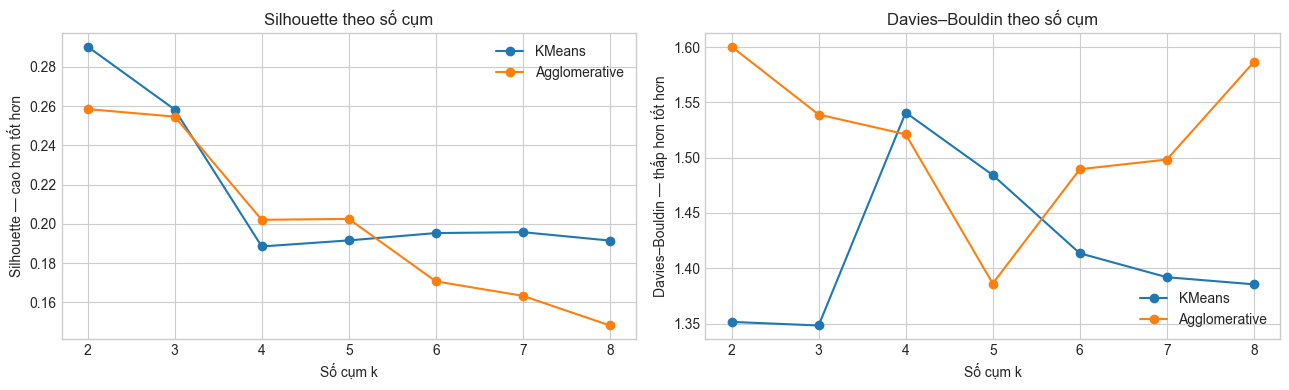

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for algorithm in results_df["algorithm"].unique():
    subset = results_df[results_df["algorithm"] == algorithm]

    axes[0].plot(
        subset["k"],
        subset["silhouette"],
        marker="o",
        label=algorithm
    )

    axes[1].plot(
        subset["k"],
        subset["davies_bouldin"],
        marker="o",
        label=algorithm
    )

axes[0].set_title("Silhouette theo số cụm")
axes[0].set_xlabel("Số cụm k")
axes[0].set_ylabel("Silhouette — cao hơn tốt hơn")
axes[0].legend()

axes[1].set_title("Davies–Bouldin theo số cụm")
axes[1].set_xlabel("Số cụm k")
axes[1].set_ylabel("Davies–Bouldin — thấp hơn tốt hơn")
axes[1].legend()

plt.tight_layout()
plt.show()

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

chọn model

In [10]:
# Loại các cấu hình tạo cụm quá nhỏ
minimum_reasonable_size = 20

eligible_results = results_df[
    results_df["min_cluster_size"] >= minimum_reasonable_size
].copy()

best_row = (
    eligible_results
    .sort_values(
        ["silhouette", "davies_bouldin"],
        ascending=[False, True]
    )
    .iloc[0]
)

final_algorithm = best_row["algorithm"]
final_k = int(best_row["k"])

labels_final = candidate_labels[
    (final_algorithm, final_k)
]

print("Model được chọn:", final_algorithm)
print("Số cụm:", final_k)
print("Silhouette:", round(best_row["silhouette"], 4))
print("Davies–Bouldin:", round(best_row["davies_bouldin"], 4))

print("\nKích thước từng cụm:")
display(
    pd.Series(labels_final)
    .value_counts()
    .sort_index()
    .rename("size")
)

Model được chọn: KMeans
Số cụm: 2
Silhouette: 0.2903
Davies–Bouldin: 1.3515

Kích thước từng cụm:


0    252
1    188
Name: size, dtype: int64

stability

In [11]:
# Kiểm tra độ ổn định khi đổi preprocessing

if final_algorithm == "KMeans":
    robust_model = KMeans(
        n_clusters=final_k,
        n_init=20,
        random_state=RANDOM_STATE
    )
else:
    robust_model = AgglomerativeClustering(
        n_clusters=final_k,
        linkage="ward"
    )

labels_robust = robust_model.fit_predict(X_model_robust)

preprocessing_ari = adjusted_rand_score(
    labels_final,
    labels_robust
)

print(
    "ARI giữa StandardScaler và RobustScaler:",
    round(preprocessing_ari, 4)
)


# Nếu model cuối là K-Means, kiểm tra thêm nhiều random seed
if final_algorithm == "KMeans":
    stability_rows = []

    for seed in [0, 1, 7, 21, 42, 99]:
        model_seed = KMeans(
            n_clusters=final_k,
            n_init=20,
            random_state=seed
        )

        labels_seed = model_seed.fit_predict(X_model)

        stability_rows.append({
            "seed": seed,
            "ARI_so_voi_final": adjusted_rand_score(
                labels_final,
                labels_seed
            )
        })

    stability_df = pd.DataFrame(stability_rows)
    display(stability_df)

ARI giữa StandardScaler và RobustScaler: 0.9284


,seed,ARI_so_voi_final
0,0,1.00
1,1,1.00
2,7,1.00
3,21,1.00
4,42,1.00
5,99,1.00


### Quyết định model

Em chọn **K-Means với k = 2**, sử dụng dữ liệu đã qua `log1p` và `StandardScaler`. Trong các cấu hình được thử, mô hình này có Silhouette cao nhất, khoảng `0.2903`, Davies–Bouldin khoảng `1.3515`, đồng thời tạo ra hai cụm có kích thước tương đối cân bằng là `252` và `188` khách hàng.

So với Agglomerative Clustering ở k = 2, K-Means có Silhouette cao hơn và Davies–Bouldin thấp hơn. Khi tăng số cụm, Silhouette nhìn chung giảm và một số cấu hình bắt đầu tạo ra cụm khá nhỏ, nên em không chọn các giá trị k lớn hơn.

Kết quả cũng khá ổn định. Khi thay StandardScaler bằng RobustScaler, ARI đạt `0.9284`. Khi đổi nhiều random seed, ARI đều bằng `1.0`, nghĩa là kết quả K-Means gần như không thay đổi.

Tuy nhiên, Silhouette `0.2903` chỉ ở mức vừa phải, cho thấy hai cụm vẫn còn chồng lấn. Vì vậy em xem đây là một segmentation để thử nghiệm giới hạn, chưa phải cấu trúc nhóm hoàn toàn chắc chắn.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


Tổng explained variance của PCA 2D: 0.7127


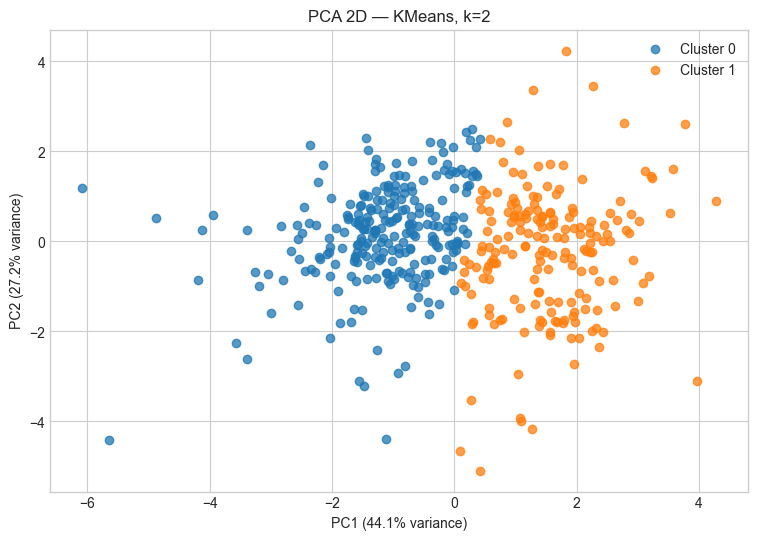

In [12]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

coords = pca.fit_transform(X_model)

explained_ratio = pca.explained_variance_ratio_

print(
    "Tổng explained variance của PCA 2D:",
    round(explained_ratio.sum(), 4)
)

plt.figure(figsize=(9, 6))

for cluster_id in sorted(np.unique(labels_final)):
    mask = labels_final == cluster_id

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.75
    )

plt.title(
    f"PCA 2D — {final_algorithm}, k={final_k}"
)
plt.xlabel(
    f"PC1 ({explained_ratio[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({explained_ratio[1] * 100:.1f}% variance)"
)
plt.legend()
plt.show()

### Giới hạn của PCA 2D

Model được fit trên toàn bộ sáu chiều của `X_model`, không phải chỉ trên hai trục PCA.

Biểu đồ PCA giúp quan sát mức độ chồng lấn và vị trí tương đối giữa các cụm. Tuy nhiên, đây chỉ là phép chiếu từ sáu chiều xuống hai chiều nên có thể làm mất thông tin. Vì vậy em không dùng hình PCA làm bằng chứng duy nhất để khẳng định các cụm đã tách hoàn toàn.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [13]:
profile_data = X_raw.copy()
profile_data["cluster"] = labels_final

cluster_sizes = (
    profile_data["cluster"]
    .value_counts()
    .sort_index()
    .rename("size")
)

profile_median = (
    profile_data
    .groupby("cluster")[SPENDING_FEATURES]
    .median()
)

profile_mean = (
    profile_data
    .groupby("cluster")[SPENDING_FEATURES]
    .mean()
)

overall_median = X_raw.median()

relative_profile = (
    profile_median / overall_median
)

print("Kích thước cụm:")
display(cluster_sizes)

print("\nMedian chi tiêu theo cụm — đơn vị gốc:")
display(profile_median)

print("\nMean chi tiêu theo cụm — đơn vị gốc:")
display(profile_mean)

print("\nTỷ lệ median cụm so với median toàn bộ:")
display(relative_profile)

Kích thước cụm:


cluster
0    252
1    188
Name: size, dtype: int64


Median chi tiêu theo cụm — đơn vị gốc:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"10,347.50","1,871.00","2,406.00","2,225.00",327.50,749.50
1,"5,406.50","7,690.50","11,527.00","1,061.50","4,495.00","1,388.50"



Mean chi tiêu theo cụm — đơn vị gốc:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"13,973.13","2,401.75","2,918.71","3,705.67",491.94,"1,038.04"
1,"9,355.87","10,346.36","14,697.06","2,222.45","6,084.51","2,177.43"



Tỷ lệ median cụm so với median toàn bộ:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,1.22,0.52,0.51,1.46,0.40,0.78
1,0.64,2.12,2.42,0.70,5.51,1.44


gợi ý tên cụm

In [14]:
def suggest_cluster_name(row):
    # Cụm thấp trên phần lớn danh mục
    if (row < 1).sum() >= 5 and row.median() < 0.8:
        return "Chi tiêu thấp đa danh mục"

    # Cụm cao trên phần lớn danh mục
    if (row > 1).sum() >= 5 and row.median() > 1.2:
        return "Chi tiêu cao đa danh mục"

    top_features = (
        row.sort_values(ascending=False)
        .head(2)
        .index
        .tolist()
    )

    return (
        f"Thiên về {top_features[0]} "
        f"và {top_features[1]}"
    )


cluster_names = relative_profile.apply(
    suggest_cluster_name,
    axis=1
)

profile_report = profile_median.copy()
profile_report.insert(
    0,
    "cluster_name",
    cluster_names
)
profile_report.insert(
    1,
    "size",
    cluster_sizes
)

display(profile_report)

,cluster_name,size,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,,,
0,Thiên về Frozen và Fresh,252,"10,347.50","1,871.00","2,406.00","2,225.00",327.50,749.50
1,Thiên về Detergents_Paper và Grocery,188,"5,406.50","7,690.50","11,527.00","1,061.50","4,495.00","1,388.50"


visual profile

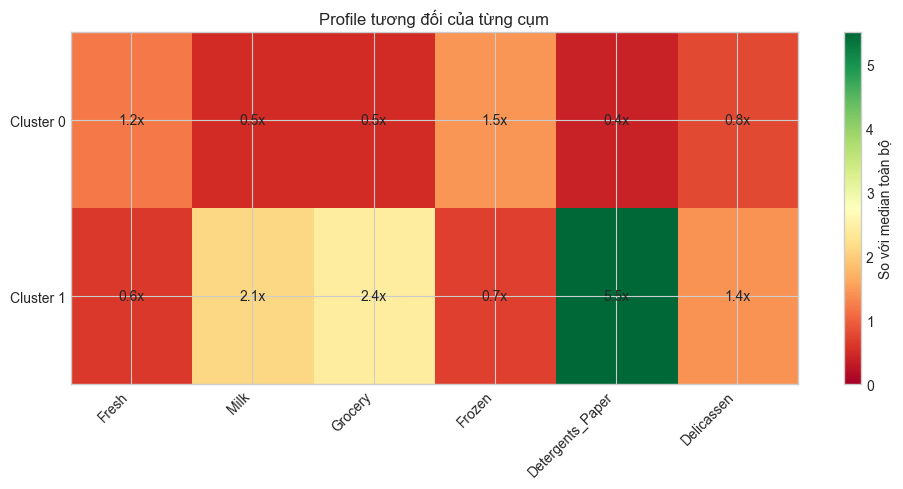

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

image = ax.imshow(
    relative_profile,
    cmap="RdYlGn",
    aspect="auto",
    vmin=0,
    vmax=max(2, relative_profile.max().max())
)

ax.set_xticks(range(len(SPENDING_FEATURES)))
ax.set_xticklabels(
    SPENDING_FEATURES,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(relative_profile.index)))
ax.set_yticklabels(
    [
        f"Cluster {cluster_id}"
        for cluster_id in relative_profile.index
    ]
)

for i in range(relative_profile.shape[0]):
    for j in range(relative_profile.shape[1]):
        ax.text(
            j,
            i,
            f"{relative_profile.iloc[i, j]:.1f}x",
            ha="center",
            va="center"
        )

plt.colorbar(image, ax=ax, label="So với median toàn bộ")
plt.title("Profile tương đối của từng cụm")
plt.tight_layout()
plt.show()

Kiểm tra Channel và Region sau clustering

In [16]:
context_df = df.copy()
context_df["cluster"] = labels_final

for context_col in ["Channel", "Region"]:
    if context_col in context_df.columns:
        print(f"\nTỷ lệ {context_col} trong từng cluster:")

        context_table = pd.crosstab(
            context_df["cluster"],
            context_df[context_col],
            normalize="index"
        )

        display(context_table)


Tỷ lệ Channel trong từng cluster:


Channel,1,2
cluster,,
0,0.97,0.03
1,0.29,0.71


### Action hypothesis

**Nhóm thiên về Fresh và Frozen — 252 khách hàng**

Median `Fresh` của nhóm này khoảng `10,347.5`, bằng `1.22` lần median toàn bộ; `Frozen` khoảng `2,225`, bằng `1.46` lần median toàn bộ. Ngược lại, chi tiêu cho `Milk`, `Grocery` và `Detergents_Paper` thấp hơn đáng kể.

Có thể thử nghiệm lịch giao hàng thường xuyên hơn, ưu đãi theo sản lượng hoặc dịch vụ vận chuyển và bảo quản lạnh. Hiệu quả nên được đánh giá bằng doanh thu tăng thêm, tần suất mua lại và lợi nhuận sau chi phí giao hàng.

**Nhóm thiên về Detergents_Paper, Grocery và Milk — 188 khách hàng**

Median `Detergents_Paper` của nhóm này cao gấp khoảng `5.51` lần median toàn bộ; `Grocery` cao gấp `2.42` lần và `Milk` cao gấp `2.12` lần. Ngoài ra, khoảng `71%` khách hàng trong nhóm thuộc Channel 2.

Có thể thử bundle các mặt hàng tiêu dùng, chương trình đặt hàng định kỳ hoặc chiết khấu theo tổng giá trị đơn hàng. Đây mới là giả thuyết cần kiểm chứng, không phải kết luận chắc chắn.

Trước khi triển khai rộng, cần thêm dữ liệu về biên lợi nhuận, tần suất mua, lịch sử giao dịch, chi phí phục vụ, phản hồi campaign và khả năng khách hàng rời bỏ.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


# Executive summary

Kết quả phân tích cho thấy segmentation này nên được dùng cho một thử nghiệm giới hạn, chưa nên áp dụng ngay cho mọi quyết định kinh doanh. Em chọn K-Means với k = 2 trên dữ liệu đã biến đổi `log1p` và StandardScaler. Cấu hình này đạt Silhouette `0.2903` và Davies–Bouldin `1.3515`. Silhouette chưa cao, nhưng hai cụm có quy mô khá cân bằng, gồm `252` và `188` khách hàng. Kết quả ổn định khi đổi random seed với ARI bằng `1.0`, đồng thời vẫn gần như giữ nguyên khi thay StandardScaler bằng RobustScaler, với ARI `0.9284`.

Cụm thứ nhất thiên về Fresh và Frozen: median Fresh khoảng `10,348` và Frozen khoảng `2,225`, trong khi Grocery, Milk và Detergents_Paper thấp hơn median toàn bộ. Cụm thứ hai thiên mạnh về Detergents_Paper, Grocery và Milk, lần lượt khoảng `5.51`, `2.42` và `2.12` lần median chung.

Em đề xuất thử giao hàng lạnh theo lịch và ưu đãi sản lượng cho cụm thứ nhất. Với cụm thứ hai, có thể thử bundle sản phẩm và chương trình đặt hàng định kỳ. Hiệu quả nên được đánh giá bằng tỷ lệ phản hồi, doanh thu tăng thêm và lợi nhuận sau chi phí. Giới hạn lớn nhất là dữ liệu chỉ có tổng chi tiêu năm, chưa có tần suất mua, biên lợi nhuận, thời gian giao dịch và phản hồi campaign.